In [1]:
import torch
import torchvision
from torch import nn, optim
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from torchvision import transforms, datasets
from models.GhostNet import GhostNet
from models.MobileNetV2 import MobileNetV2
from models.MobileNetV3 import MobileNetV3
from models.ShuffleNetV2 import ShuffleNetV2
from models.ResNet18 import resnet18

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
def preprocessing(tensor):
    if tensor.mean() > 0.5:
        tensor = 1 - tensor
    return tensor

In [4]:
def tensor_transform(x):
    if x.shape[1] == 1:
        return x.repeat_interleave(3, dim= 1)
    elif x.shape[1] == 4:
        return x[:, :3, :, :]
    elif x.shape[1] == 3:
        return x
    else:
        raise ValueError('Invalid input shape')

tensor_rgb_transform = transforms.Lambda(tensor_transform)

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Lambda(preprocessing),
    transforms.Normalize((0.1307, ), (0.3081, )),
    transforms.Grayscale(1)
])

In [6]:
test_db = datasets.ImageFolder(root= 'C:/Users/Administrator/Desktop/datas/test_data_black', transform= transform)
test_loader = DataLoader(test_db, batch_size= 10, shuffle= True)

In [7]:
mnist_db = datasets.MNIST(root='dataFolder/', transform= transform, train=True, download=True)
mnist_loader = DataLoader(mnist_db, batch_size=100, shuffle=True)

In [8]:
x, y = next(iter(test_loader))

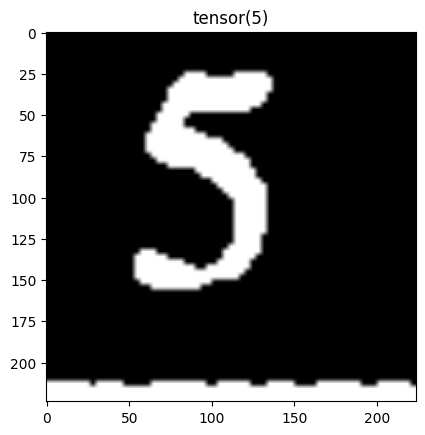

In [9]:
plt.figure()
plt.imshow(x[0][0].detach().numpy(), cmap='gray')
plt.title(y[0])
plt.show()

In [10]:
ghost_1c_od = GhostNet(n_classes= 10, in_ch= 1)
ghost_1c_od.load_state_dict(torch.load('save_models/OD/GhostNet_1C_OD_42.pth'))
ghost_1c_od.to(device)
ghost_1c_od.eval()
print('GhostNet 1C OD 已载入.')

GhostNet 1C OD 已载入.


In [11]:
ghost_3c_od = GhostNet(n_classes= 10, in_ch= 3)
ghost_3c_od.load_state_dict(torch.load('save_models/OD/GhostNet_3C_OD_42.pth'))
ghost_3c_od.to(device)
ghost_3c_od.eval()
print('GhostNet 3C OD 已载入.')

GhostNet 3C OD 已载入.


In [12]:
mobV2_1c_od = MobileNetV2(n_classes=10, in_ch= 1)
mobV2_1c_od.load_state_dict(torch.load('save_models/OD/MobileNetV2_1C_OD_42.pth'))
mobV2_1c_od.to(device)
mobV2_1c_od.eval()
print('MobileNetV2 1C OD 已载入.')

MobileNetV2 1C OD 已载入.


In [13]:
mobV2_3c_od = MobileNetV2(n_classes=10, in_ch= 3)
mobV2_3c_od.load_state_dict(torch.load('save_models/OD/MobileNetV2_3C_OD_42.pth'))
mobV2_3c_od.to(device)
mobV2_3c_od.eval()
print('MobileNetV2 3C OD 已载入.')

MobileNetV2 3C OD 已载入.


In [14]:
mobV3_1c_od = MobileNetV3(version= 'small', in_ch= 1)
mobV3_1c_od.load_state_dict(torch.load('save_models/OD/MobileNetV3_1C_OD_42.pth'))
mobV3_1c_od.to(device)
mobV3_1c_od.eval()
print('MobileNetV3 1C OD 已载入.')

MobileNetV3 1C OD 已载入.


In [15]:
mobV3_3c_od = MobileNetV3(version= 'small', in_ch= 3)
mobV3_3c_od.load_state_dict(torch.load('save_models/OD/MobileNetV3_3C_OD_42.pth'))
mobV3_3c_od.to(device)
mobV3_3c_od.eval()
print('MobileNetV3 3C OD 已载入.')

MobileNetV3 3C OD 已载入.


In [16]:
shufV2_1c_od = ShuffleNetV2(in_ch= 1)
shufV2_1c_od.load_state_dict(torch.load('save_models/OD/ShuffleNetV2_1C_OD_42.pth'))
shufV2_1c_od.to(device)
shufV2_1c_od.eval()
print('ShuffleNetV2 1C OD 已载入.')

model size is 1.0x
ShuffleNetV2 1C OD 已载入.


In [17]:
shufV2_3c_od = ShuffleNetV2(in_ch= 3)
shufV2_3c_od.load_state_dict(torch.load('save_models/OD/ShuffleNetV2_3C_OD_42.pth'))
shufV2_3c_od.to(device)
shufV2_3c_od.eval()
print('ShuffleNetV2 3C OD 已载入.')

model size is 1.0x
ShuffleNetV2 3C OD 已载入.


In [18]:
resnet18_1c_od = resnet18(in_ch= 1)
resnet18_1c_od.load_state_dict(torch.load('save_models/OD/resnet18_1C_OD_42.pth'))
resnet18_1c_od.to(device)
resnet18_1c_od.eval()
print('resnet18 1C OD 已载入.')

resnet18 1C OD 已载入.


In [19]:
resnet18_3c_od = resnet18(in_ch= 3)
resnet18_3c_od.load_state_dict(torch.load('save_models/OD/resnet18_3C_OD_42.pth'))
resnet18_3c_od.to(device)
resnet18_3c_od.eval()
print('resnet18 3C OD 已载入.')

resnet18 3C OD 已载入.


In [20]:
idxs = []
total = 0
correct_ghost_1c, correct_mobv2_1c, correct_mobv3_1c, correct_shufv2_1c, correct_resnet18_1c = 0, 0, 0, 0, 0
correct_ghost_3c, correct_mobv2_3c, correct_mobv3_3c, correct_shufv2_3c, correct_resnet18_3c = 0, 0, 0, 0, 0
# correct_ghosts, correct_mobv2s, correct_mobv3s, correct_shufv2s, correct_resnet18s = [], [], [], [], []
with torch.no_grad():
    for idx, (x, y) in enumerate(test_loader):
        x, y = x.to(device), y.to(device)
        # plt.imshow(x[0].permute(1, 2, 0).cpu().numpy(), cmap='gray')
        # plt.show()

        x_rgb = tensor_rgb_transform(x)
        out_ghost_1c = torch.argmax(ghost_1c_od(x), dim= -1)
        out_ghost_3c = torch.argmax(ghost_3c_od(x_rgb), dim= -1)

        out_mobv2_1c = torch.argmax(mobV2_1c_od(x), dim= -1)
        out_mobv2_3c = torch.argmax(mobV2_3c_od(x_rgb), dim= -1)

        out_mobv3_1c = torch.argmax(mobV3_1c_od(x), dim= -1)
        out_mobv3_3c = torch.argmax(mobV3_3c_od(x_rgb), dim= -1)

        out_shufv2_1c = torch.argmax(shufV2_1c_od(x), dim= -1)
        out_shufv2_3c = torch.argmax(shufV2_3c_od(x_rgb), dim= -1)

        out_resnet18_1c = torch.argmax(resnet18_1c_od(x), dim= -1)
        out_resnet18_3c = torch.argmax(resnet18_3c_od(x_rgb), dim= -1)

        total += x.shape[0]

        correct_ghost_1c += (out_ghost_1c == y).sum().item()
        correct_mobv2_1c += (out_mobv2_1c == y).sum().item()
        correct_mobv3_1c += (out_mobv3_1c == y).sum().item()
        correct_shufv2_1c += (out_shufv2_1c == y).sum().item()
        correct_resnet18_1c += (out_resnet18_1c == y).sum().item()

        correct_ghost_3c += (out_ghost_3c == y).sum().item()
        correct_mobv2_3c += (out_mobv2_3c == y).sum().item()
        correct_mobv3_3c += (out_mobv3_3c == y).sum().item()
        correct_shufv2_3c += (out_shufv2_3c == y).sum().item()
        correct_resnet18_3c += (out_resnet18_3c == y).sum().item()

        if idx % 50 == 0:
            accu_ghost_1c = correct_ghost_1c / total
            accu_mobv2_1c = correct_mobv2_1c / total
            accu_mobv3_1c = correct_mobv3_1c / total
            accu_shufv2_1c = correct_shufv2_1c / total
            accu_resnet18_1c = correct_resnet18_1c / total

            accu_ghost_3c = correct_ghost_3c / total
            accu_mobv2_3c = correct_mobv2_3c / total    
            accu_mobv3_3c = correct_mobv3_3c / total
            accu_shufv2_3c = correct_shufv2_3c / total
            accu_resnet18_3c = correct_resnet18_3c / total

            print(f"idx: {idx}, accu_ghost_1c: {accu_ghost_1c:.4f}, accu_mobv2_1c: {accu_mobv2_1c:.4f}, accu_mobv3_1c: {accu_mobv3_1c:.4f}, accu_shufv2_1c: {accu_shufv2_1c:.4f}, accu_resnet18_1, {accu_resnet18_1c:.4f}")
            print(f"idx: {idx}, accu_ghost_3c: {accu_ghost_3c:.4f}, accu_mobv2_3c: {accu_mobv2_3c:.4f}, accu_mobv3_3c: {accu_mobv3_3c:.4f}, accu_shufv2_3c: {accu_shufv2_3c:.4f}, accu_resnet18_3, {accu_resnet18_1c:.4f}")

            with open('data_csv/OD_data.csv', 'a+') as f:
                f.writelines(f"{idx}, {1}, {accu_ghost_1c:.4f}, {accu_mobv2_1c:.4f}, {accu_mobv3_1c:.4f}, {accu_shufv2_1c:.4f}, {accu_resnet18_1c:.4f}\n")
                f.writelines(f"{idx}, {3}, {accu_ghost_3c:.4f}, {accu_mobv2_3c:.4f}, {accu_mobv3_3c:.4f}, {accu_shufv2_3c:.4f}, {accu_resnet18_3c:.4f}\n")

idx: 0, accu_ghost_1c: 0.9000, accu_mobv2_1c: 1.0000, accu_mobv3_1c: 1.0000, accu_shufv2_1c: 1.0000, accu_resnet18_1, 1.0000
idx: 0, accu_ghost_3c: 1.0000, accu_mobv2_3c: 1.0000, accu_mobv3_3c: 1.0000, accu_shufv2_3c: 1.0000, accu_resnet18_3, 1.0000
idx: 50, accu_ghost_1c: 0.9667, accu_mobv2_1c: 0.9882, accu_mobv3_1c: 0.9980, accu_shufv2_1c: 0.9961, accu_resnet18_1, 0.9980
idx: 50, accu_ghost_3c: 0.9784, accu_mobv2_3c: 1.0000, accu_mobv3_3c: 0.9961, accu_shufv2_3c: 0.9980, accu_resnet18_3, 0.9980
idx: 100, accu_ghost_1c: 0.9663, accu_mobv2_1c: 0.9802, accu_mobv3_1c: 0.9990, accu_shufv2_1c: 0.9960, accu_resnet18_1, 0.9980
idx: 100, accu_ghost_3c: 0.9752, accu_mobv2_3c: 0.9980, accu_mobv3_3c: 0.9960, accu_shufv2_3c: 0.9980, accu_resnet18_3, 0.9980
idx: 150, accu_ghost_1c: 0.9689, accu_mobv2_1c: 0.9821, accu_mobv3_1c: 0.9967, accu_shufv2_1c: 0.9954, accu_resnet18_1, 0.9980
idx: 150, accu_ghost_3c: 0.9781, accu_mobv2_3c: 0.9980, accu_mobv3_3c: 0.9954, accu_shufv2_3c: 0.9967, accu_resnet18_